# `PlaneWave` — Onde plane

**Fichier source :** `src/quantum_sim/waves/plane_wave.py`

---

## 1. Contexte physique

L'**onde plane** est la solution la plus simple de l'équation de Schrödinger pour une particule libre (sans potentiel). Elle représente un état de **quantité de mouvement définie**, c'est-à-dire un état propre de l'opérateur impulsion $\hat{p}$.

### 1.1 Expression mathématique

$$
\psi(x, t) = A \cdot e^{i(k(x - x_0) - \omega t + \phi)}
$$

| Symbole | Nom | Unité SI |
|---|---|---|
| $A$ | Amplitude complexe | sans dimension |
| $k$ | Nombre d'onde | m⁻¹ |
| $x_0$ | Position initiale de référence | m |
| $\omega$ | Pulsation angulaire | rad·s⁻¹ |
| $\phi$ | Phase initiale | rad |
| $t$ | Temps | s |

### 1.2 Relation de dispersion — particule libre

Pour une particule quantique libre de masse $m$, l'énergie cinétique est :

$$
E = \frac{p^2}{2m} = \frac{(\hbar k)^2}{2m}
$$

Or $E = \hbar \omega$, donc la **relation de dispersion** est :

$$
\omega = \frac{\hbar k^2}{2m}
$$

---

## 2. Grandeurs physiques dérivées

### Impulsion
$$
p = \hbar k
$$
L'onde plane est un état propre de $\hat{p}$ avec valeur propre $\hbar k$.

### Énergie
$$
E = \frac{p^2}{2m} = \frac{\hbar^2 k^2}{2m}
$$

### Vitesse de phase
La vitesse à laquelle se déplace la surface de phase constante :
$$
v_\phi = \frac{\omega}{k} = \frac{\hbar k}{2m} = \frac{p}{2m}
$$


### Longueur d'onde
$$
\lambda = \frac{2\pi}{k}
$$

### Période
$$
T = \frac{2\pi}{\omega}
$$

---

## 3. Propriété importante : densité de probabilité uniforme

$$
|\psi(x, t)|^2 = |A|^2
$$

La densité de probabilité est **constante** dans l'espace. L'onde plane n'est donc pas normalisable sur $\mathbb{R}$ entier — elle est un **idéal théorique**. En pratique, on travaille avec des **paquets d'ondes** (voir `WavePacket` et `GaussianWavePacket`).

---

## 4. Code source annoté

In [1]:
import numpy as np

# Constantes physiques (issues de quantum_sim.utils.constants)
PLANCK_CONSTANT = 6.62607015e-34      # J·s
REDUCED_PLANCK_CONSTANT = PLANCK_CONSTANT / (2 * np.pi)  # ħ
ELECTRON_MASS = 9.10938356e-31        # kg
PI = np.pi

class PlaneWave:
    """
    Onde plane quantique : ψ(x,t) = A · exp(i(k(x - x₀) - ωt + φ))
    Implémente WaveFunction (classe de base abstraite).
    """

    def __init__(self, amplitude, wave_number, position=0.0,
                 phase=0.0, time=0.0, masse=ELECTRON_MASS):
        self.amplitude = amplitude      # A : amplitude complexe
        self.wave_number = wave_number  # k : nombre d'onde (m⁻¹)
        self.position = position        # x₀ : offset spatial
        self.phase = phase              # φ : phase initiale
        self.time = time                # t  : paramètre temporel
        self.masse = masse              # m  : masse de la particule

    @property
    def angular_frequency(self):
        """ω = ħk²/(2m) — relation de dispersion quadratique"""
        return (REDUCED_PLANCK_CONSTANT * self.wave_number**2) / (2 * self.masse)

    @property
    def momentum(self):
        """p = ħk"""
        return REDUCED_PLANCK_CONSTANT * self.wave_number

    @property
    def energy(self):
        """E = p²/(2m)"""
        return self.momentum**2 / (2 * self.masse)

    @property
    def phase_velocity(self):
        """v_φ = ω/k = ħk/(2m)"""
        return self.angular_frequency / self.wave_number

    @property
    def wavelength(self):
        """λ = 2π/k"""
        return 2 * PI / self.wave_number

    @property
    def period(self):
        """T = 2π/ω"""
        return 2 * PI / self.angular_frequency

    def evaluate(self, x):
        """Évalue ψ(x, t) = A · exp(i(k(x-x₀) - ωt + φ))"""
        phase = self.wave_number * (x - self.position) \
                - self.angular_frequency * self.time \
                + self.phase
        return self.amplitude * np.exp(1j * phase)

## 5. Exploration des propriétés physiques

In [2]:
import numpy as np
import matplotlib.pyplot as plt

hbar = 1.054571817e-34
m_e = 9.10938356e-31

# Onde plane d'un électron avec k = 1e10 m⁻¹ (~ niveau atomique)
k = 1e10   # m⁻¹
pw = PlaneWave(amplitude=1.0, wave_number=k, masse=m_e)

print("=== Propriétés de l'onde plane ===")
print(f"Nombre d'onde       k  = {pw.wave_number:.3e} m⁻¹")
print(f"Longueur d'onde     λ  = {pw.wavelength:.3e} m")
print(f"Impulsion           p  = {pw.momentum:.3e} kg·m/s")
print(f"Pulsation           ω  = {pw.angular_frequency:.3e} rad/s")
print(f"Période             T  = {pw.period:.3e} s")
print(f"Énergie             E  = {pw.energy:.3e} J  ({pw.energy/1.6e-19:.2f} eV)")
print(f"Vitesse de phase    vφ = {pw.phase_velocity:.3e} m/s")
print(f"Vitesse de groupe   vg = {2*pw.phase_velocity:.3e} m/s")

=== Propriétés de l'onde plane ===
Nombre d'onde       k  = 1.000e+10 m⁻¹
Longueur d'onde     λ  = 6.283e-10 m
Impulsion           p  = 1.055e-24 kg·m/s
Pulsation           ω  = 5.788e+15 rad/s
Période             T  = 1.085e-15 s
Énergie             E  = 6.104e-19 J  (3.82 eV)
Vitesse de phase    vφ = 5.788e+05 m/s
Vitesse de groupe   vg = 1.158e+06 m/s


## 6. Visualisation : parties réelle, imaginaire et densité de probabilité

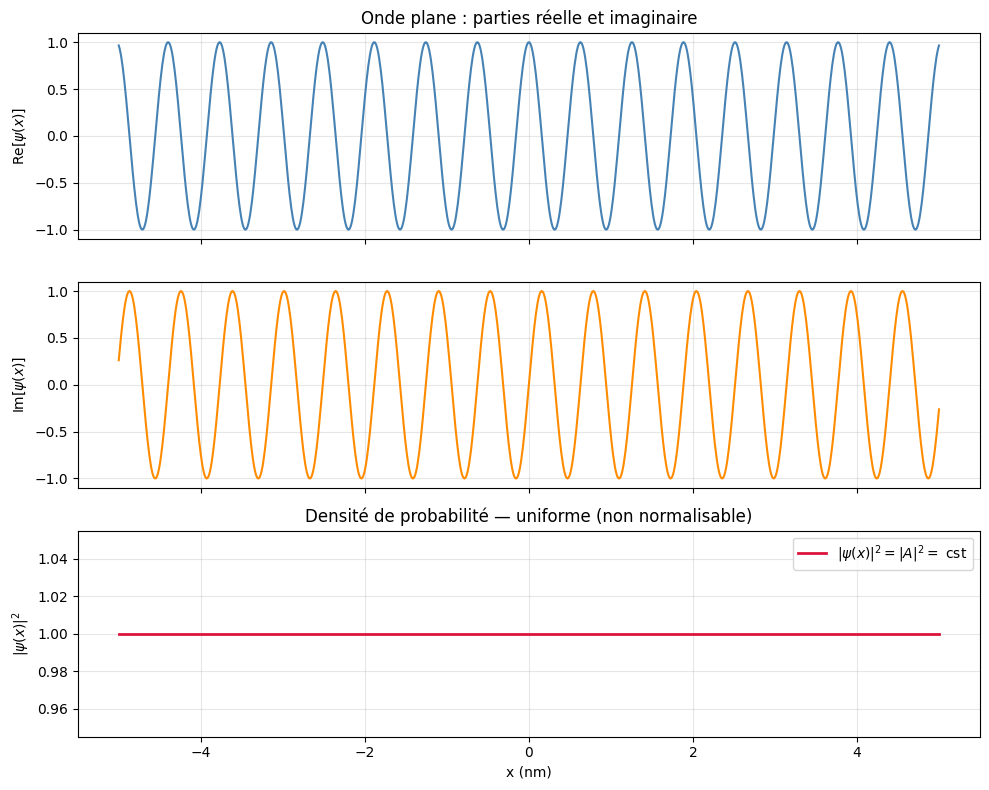

In [3]:
x = np.linspace(-5e-9, 5e-9, 1000)  # grille en nanomètres
psi = pw.evaluate(x)
prob = np.abs(psi)**2

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(x*1e9, psi.real, color='steelblue', lw=1.5)
axes[0].set_ylabel(r'Re$[\psi(x)]$')
axes[0].set_title('Onde plane : parties réelle et imaginaire')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x*1e9, psi.imag, color='darkorange', lw=1.5)
axes[1].set_ylabel(r'Im$[\psi(x)]$')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x*1e9, prob, color='crimson', lw=2, label=r'$|\psi(x)|^2 = |A|^2 = $ cst')
axes[2].set_ylabel(r'$|\psi(x)|^2$')
axes[2].set_xlabel('x (nm)')
axes[2].set_title('Densité de probabilité — uniforme (non normalisable)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Propagation temporelle

On visualise comment la phase se déplace dans le temps avec la vitesse de phase $v_\phi = \omega / k$.

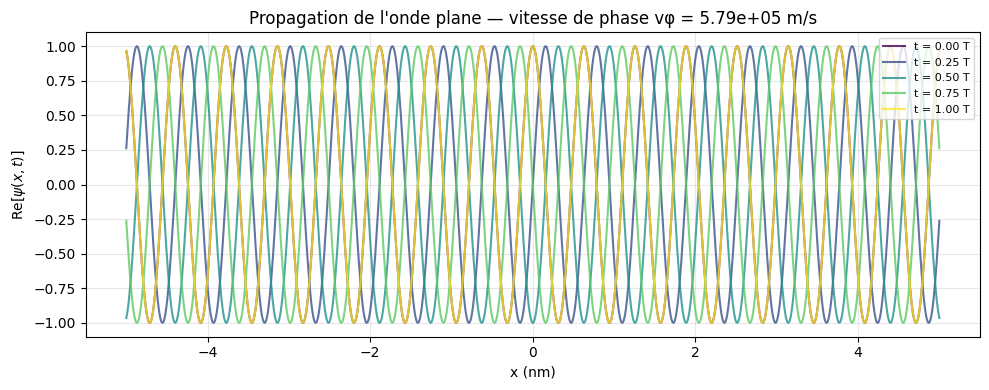

In [4]:
x = np.linspace(-5e-9, 5e-9, 1000)
fig, ax = plt.subplots(figsize=(10, 4))

times = np.linspace(0, pw.period, 5)  # 5 instants sur une période
colors = plt.cm.viridis(np.linspace(0, 1, len(times)))

for t, color in zip(times, colors):
    pw_t = PlaneWave(amplitude=1.0, wave_number=k, time=t, masse=m_e)
    psi_t = pw_t.evaluate(x)
    label = f't = {t/pw.period:.2f} T'
    ax.plot(x*1e9, psi_t.real, color=color, alpha=0.8, label=label)

ax.set_xlabel('x (nm)')
ax.set_ylabel(r'Re$[\psi(x, t)]$')
ax.set_title(f'Propagation de l\'onde plane — vitesse de phase vφ = {pw.phase_velocity:.2e} m/s')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Résumé

| Grandeur | Formule | Code Python |
|---|---|---|
| Onde plane | $A e^{i(k(x-x_0)-\omega t+\phi)}$ | `evaluate(x)` |
| Pulsation | $\omega = \hbar k^2 / 2m$ | `angular_frequency` |
| Impulsion | $p = \hbar k$ | `momentum` |
| Énergie | $E = p^2/2m$ | `energy` |
| Vitesse de phase | $v_\phi = \omega/k$ | `phase_velocity` |
| Longueur d'onde | $\lambda = 2\pi/k$ | `wavelength` |
| Densité de probabilité | $|\psi|^2 = |A|^2 = $ cst | `probability_density(x)` |